# v2 training-run explorer

Read-only analysis of the staged **pretrain → anneal** run for the Qwen3-0.6B
from-scratch model. Nothing in this notebook mutates checkpoints or logs.

It pulls from three sources, cheapest first:

1. **`logs/*.log`** — per-step train metrics, evals, and in-training samples (plain text).
2. **`checkpoints/*.pt`** — the `val_history` list saved inside each checkpoint, read
   via `mmap` so we *don't* pull the 3.5 GB of weights into RAM.
3. **a single model**, loaded on demand into the GPU for live inference samples.

> **Run note (2026-06):** the `anneal_final.pt` currently on disk is from the
> pre-fix *no-op* anneal run — it ran 0 steps, so its single eval is identical to
> the pretrain final. The pretrain curve (80 evals) is fully populated; the anneal
> curves will fill in once a proper `anneal.sh` run completes. The notebook is
> built to reflect whatever is on disk honestly.

A glossary of *which metrics matter and why* is at the bottom.

## 0 · Setup

In [1]:
from __future__ import annotations

import re, sys, math, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook lives in <v2>/notebooks/ ; resolve the project from there.
NB_DIR   = Path.cwd()
V2_DIR   = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
SRC_DIR  = V2_DIR / "src"
LOG_DIR  = V2_DIR / "logs"
CKPT_DIR = V2_DIR / "checkpoints"
assert SRC_DIR.exists(), f"can't find src/ from {NB_DIR}; open this notebook from <v2>/notebooks/"
sys.path.insert(0, str(SRC_DIR))

# Global step at which pretrain ends and anneal continues.
PRETRAIN_END_STEP = 20_000

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("v2 dir :", V2_DIR)
print("logs   :", len(list(LOG_DIR.glob("*.log"))), "files in", LOG_DIR)
print("ckpts  :", len(list(CKPT_DIR.glob("*.pt"))), "files in", CKPT_DIR)

v2 dir : /home/bmartins/dev/llm_training/models/v2
logs   : 16 files in /home/bmartins/dev/llm_training/models/v2/logs
ckpts  : 22 files in /home/bmartins/dev/llm_training/models/v2/checkpoints


## 1 · Datasets & mixtures (what the model was trained on)

Both stages draw from the **same five streaming sources** — only the sampling
*weights* change. Pre-training uses a broad mix; annealing up-weights **math**
and **arxiv** while down-weighting wiki / books / stackoverflow. So "the pretrain
data" and "the anneal data" are the *same corpora*, reweighted.

The table and bar chart below are read straight from `src/data.py`
(`SOURCES`, `PRETRAIN_MIX`, `ANNEAL_MIX`) — no network needed. The next cell
then streams a few **raw documents** from each source so you can eyeball exactly
what went in (streaming mode: a handful of docs each, nothing downloaded in
full). Set `SHOW_DATASET_SAMPLES = False` to skip the network pull.


/home/bmartins/dev/llm_training/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,source,hf_path,hf_config,field,pretrain_w,anneal_w
0,wiki,wikimedia/wikipedia,20231101.en,text,15%,5%
1,books,emozilla/pg19,,text,15%,5%
2,stackoverflow,mikex86/stackoverflow-posts,,Body,20%,10%
3,arxiv,neuralwork/arxiver,,markdown,25%,40%
4,math,open-web-math/open-web-math,,text,25%,40%


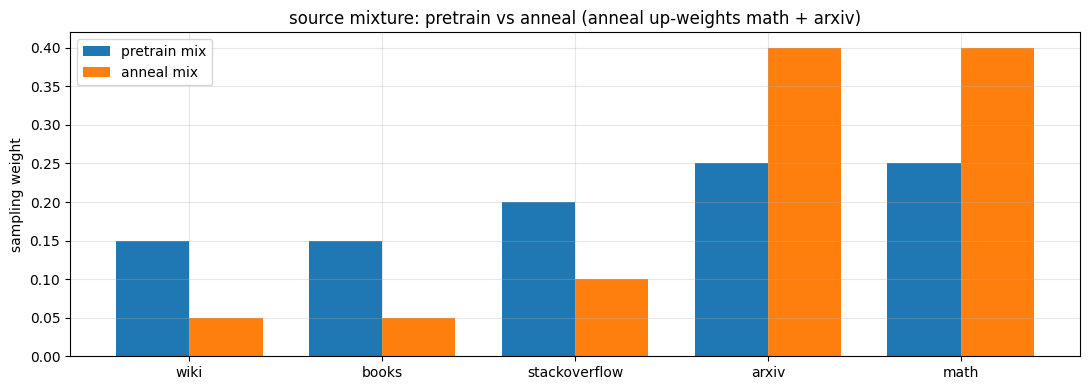

In [2]:
from data import SOURCES, PRETRAIN_MIX, ANNEAL_MIX

# Mixture table + chart — purely local, just reads the config in src/data.py.
mix_df = pd.DataFrame([
    dict(source=name,
         hf_path=spec.hf_path,
         hf_config=spec.hf_config or "",
         field=spec.text_field,
         pretrain_w=PRETRAIN_MIX.weights.get(name, 0.0),
         anneal_w=ANNEAL_MIX.weights.get(name, 0.0))
    for name, spec in SOURCES.items()
])
display(mix_df.assign(
    pretrain_w=lambda d: d["pretrain_w"].map("{:.0%}".format),
    anneal_w=lambda d: d["anneal_w"].map("{:.0%}".format),
))

x = np.arange(len(mix_df)); w = 0.38
plt.figure(figsize=(11, 4))
plt.bar(x - w/2, mix_df["pretrain_w"], w, label="pretrain mix")
plt.bar(x + w/2, mix_df["anneal_w"],   w, label="anneal mix")
plt.xticks(x, mix_df["source"]); plt.ylabel("sampling weight")
plt.title("source mixture: pretrain vs anneal (anneal up-weights math + arxiv)")
plt.legend(); plt.tight_layout(); plt.show()


In [3]:
SHOW_DATASET_SAMPLES = True   # stream a few raw docs per source from HuggingFace
SAMPLES_PER_SOURCE   = 2
PREVIEW_CHARS        = 700

if SHOW_DATASET_SAMPLES:
    from datasets import load_dataset
    for name, spec in SOURCES.items():
        cfg = f":{spec.hf_config}" if spec.hf_config else ""
        print("=" * 100)
        print(f"SOURCE  {name}  ->  {spec.hf_path}{cfg}  (field='{spec.text_field}')")
        print(f"        pretrain weight {PRETRAIN_MIX.weights.get(name, 0):.0%} | "
              f"anneal weight {ANNEAL_MIX.weights.get(name, 0):.0%}")
        try:
            ds = load_dataset(spec.hf_path, name=spec.hf_config,
                              split=spec.split, streaming=True).take(SAMPLES_PER_SOURCE)
            for i, row in enumerate(ds):
                text = row.get(spec.text_field, "")
                if not isinstance(text, str):
                    text = str(text)
                preview = " ".join(text[:PREVIEW_CHARS].split())
                more = " ..." if len(text) > PREVIEW_CHARS else ""
                print(f"\n  [{name} #{i}]  {len(text):,} chars")
                print(f"  {preview}{more}")
        except Exception as e:
            print(f"  !! could not stream {name}: {type(e).__name__}: {e}")
        print()
else:
    print("SHOW_DATASET_SAMPLES = False -- set True to stream raw docs per source (needs network).")


SOURCE  wiki  ->  wikimedia/wikipedia:20231101.en  (field='text')
        pretrain weight 15% | anneal weight 5%

  [wiki #0]  46,064 chars
  Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism. Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations. As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism). Humans have lived in societies without formal hierarchies long before the establishment of states, realms, or empires. With th ...

  [wiki #1]  25,076 chars
  Albedo (; ) is the fraction of sunlight that is diffusely reflected by a body. It is measured on a scale from 0 (correspondin

## 2 · Parse the logs

`training.py` emits three structured line types. We scan every `*.log` and turn
them into tidy DataFrames. This is the cheap path — no torch, no GPU.

In [4]:
# The three line shapes emitted by training.py (the leading "ts | LEVEL | name |"
# prefix is ignored — we .search anywhere in the line).
#
#   step:   [anneal 12/2000 gstep=20012] loss=2.36 ppl=10.6 lr=2.98e-05 gnorm=0.14 tok/s=6,215 elapsed=.. eta=..
#   eval:   [anneal eval gstep=20250] aggregate=2.41 (ppl=11.2) took=1m02s  wiki=3.10 books=2.28 ...
#   sample: [anneal sample gstep=20000] The quick brown fox ...
RE_STEP = re.compile(
    r"\[(?P<stage>\w+) (?P<local>\d+)/(?P<max>\d+) gstep=(?P<gstep>\d+)\]\s+"
    r"loss=(?P<loss>[\d.]+)\s+ppl=(?P<ppl>[\d.,]+)\s+lr=(?P<lr>[\d.eE+-]+)\s+"
    r"gnorm=(?P<gnorm>[\d.]+)\s+tok/s=(?P<toks>[\d,]+)"
)
RE_EVAL        = re.compile(r"\[(?P<stage>\w+) eval gstep=(?P<gstep>\d+)\]\s+aggregate=(?P<agg>[\d.]+)")
RE_EVAL_DOMAIN = re.compile(r"(\w+)=([\d.]+)")
RE_SAMPLE      = re.compile(r"\[(?P<stage>\w+) sample gstep=(?P<gstep>\d+)\]\s+(?P<text>.*)$")
RE_TS          = re.compile(r"^(\d{4}-\d\d-\d\d \d\d:\d\d:\d\d)")

def _num(s: str) -> float:        # strip thousands separators
    return float(s.replace(",", ""))

def parse_logs(log_dir: Path):
    """Return (steps_df, evals_df, samples_df) parsed from every *.log."""
    steps, evals, samples = [], [], []
    for f in sorted(log_dir.glob("*.log")):
        for line in f.read_text(errors="replace").splitlines():
            mts = RE_TS.match(line)
            ts  = datetime.strptime(mts.group(1), "%Y-%m-%d %H:%M:%S") if mts else None

            m = RE_STEP.search(line)
            if m:
                steps.append(dict(stage=m["stage"], gstep=int(m["gstep"]), local=int(m["local"]),
                                  loss=float(m["loss"]), ppl=_num(m["ppl"]), lr=float(m["lr"]),
                                  gnorm=float(m["gnorm"]), tok_per_sec=_num(m["toks"]),
                                  ts=ts, log=f.name))
                continue
            m = RE_EVAL.search(line)
            if m:
                tail = line.split(")", 1)[-1]   # everything after "(ppl=..)"
                domains = {k: float(v) for k, v in RE_EVAL_DOMAIN.findall(tail) if k != "took"}
                evals.append(dict(stage=m["stage"], gstep=int(m["gstep"]),
                                  aggregate=float(m["agg"]), ts=ts, log=f.name, **domains))
                continue
            m = RE_SAMPLE.search(line)
            if m:
                samples.append(dict(stage=m["stage"], gstep=int(m["gstep"]),
                                    text=m["text"].strip(), ts=ts, log=f.name))

    def _df(rows):
        return pd.DataFrame(rows).sort_values("gstep").reset_index(drop=True) if rows else pd.DataFrame()
    return _df(steps), _df(evals), _df(samples)

steps_df, evals_df, samples_df = parse_logs(LOG_DIR)
print(f"parsed {len(steps_df)} step rows, {len(evals_df)} eval rows, {len(samples_df)} samples")
print("stages in step logs:", sorted(steps_df["stage"].unique()) if len(steps_df) else "none")
steps_df.tail(3)

parsed 4000 step rows, 14 eval rows, 8 samples
stages in step logs: ['anneal']


,stage,gstep,local,loss,ppl,lr,gnorm,tok_per_sec,ts,log
3997,anneal,21998,1998,2.3428,10.4,3.000000e-08,0.14,6230.0,2026-06-07 12:47:57,anneal_20260605_135310.log
3998,anneal,21999,1999,2.0893,8.1,1.500000e-08,0.16,6228.0,2026-06-07 12:49:21,anneal_20260605_135310.log
3999,anneal,21999,1999,2.0893,8.1,1.500000e-08,0.16,6228.0,2026-06-07 12:49:21,anneal_20260605_135309.console.log


### 2b · Pretrain per-step history from wandb

The **pretrain** stage predates the structured file logger, but it logged every
step to wandb. We read the run's local `.wandb` datastore directly (no network /
login) and pull the per-step `loss / lr / ppl / grad_norm / tok_per_sec`, then
concatenate with the anneal steps into one `train_df` covering the whole run.

In [5]:
import json as _json

def find_pretrain_wandb_run(explore_dir: Path):
    """Largest *.wandb file under notebooks/wandb/ -- that's the full pretrain run."""
    runs = sorted(explore_dir.glob("wandb/run-*/*.wandb"), key=lambda p: p.stat().st_size)
    return runs[-1] if runs else None

def parse_wandb_history(wandb_file: Path) -> pd.DataFrame:
    """Extract per-step scalar history from a local .wandb datastore."""
    from wandb.sdk.internal import datastore
    from wandb.proto import wandb_internal_pb2 as pb

    ds = datastore.DataStore(); ds.open_for_scan(str(wandb_file))
    rows = []
    while True:
        out = ds.scan_data()
        if out is None:
            break
        rec = pb.Record.FromString(out)
        if rec.WhichOneof("record_type") != "history":
            continue
        row = {}
        for it in rec.history.item:
            if len(it.nested_key) == 1:          # scalars only (skip media like train/sample)
                try:
                    row[it.nested_key[0]] = _json.loads(it.value_json)
                except Exception:
                    pass
        if "loss" in row:                        # train-step record
            rows.append(row)
    return pd.DataFrame(rows)

pretrain_steps_df = pd.DataFrame()
try:
    wf = find_pretrain_wandb_run(NB_DIR)
    if wf is not None:
        raw = parse_wandb_history(wf)
        if len(raw):
            pretrain_steps_df = pd.DataFrame({
                "stage":       "pretrain",
                "gstep":       raw["step"].astype(int),
                "loss":        raw["loss"],
                "ppl":         raw.get("ppl"),
                "lr":          raw.get("lr"),
                "gnorm":       raw.get("grad_norm"),
                "tok_per_sec": raw.get("tok_per_sec"),
                "tokens":      raw.get("tokens"),
            }).sort_values("gstep").reset_index(drop=True)
        print(f"pretrain wandb: {wf.parent.name} -> {len(pretrain_steps_df)} step rows")
    else:
        print("no wandb run found under notebooks/wandb/")
except Exception as e:
    print("wandb history unavailable (", type(e).__name__, e, ") -- continuing without pretrain train curve")

# Unified per-step training frame: pretrain (wandb) + anneal (logs).
anneal_steps_df = steps_df[steps_df["stage"] == "anneal"] if len(steps_df) else pd.DataFrame()
train_df = pd.concat([d for d in (pretrain_steps_df, anneal_steps_df) if len(d)],
                     ignore_index=True)
if len(train_df):
    train_df = train_df.sort_values("gstep").reset_index(drop=True)
print("train_df stages:", sorted(train_df["stage"].unique()) if len(train_df) else "none",
      "| total rows:", len(train_df))
train_df.groupby("stage")["gstep"].agg(["min", "max", "count"]) if len(train_df) else "no data"

pretrain wandb: run-20260514_074604-09hgh2bi -> 20000 step rows
train_df stages: ['anneal', 'pretrain'] | total rows: 24000


,min,max,count
stage,,,
anneal,20000,21999,4000
pretrain,0,19999,20000


## 3 · Validation history from the checkpoints

The per-step logs only cover what was run through the structured logger (the
anneal stage). The **full** held-out validation curve for *both* stages is stored
as `val_history` inside the checkpoints. `mmap=True` memory-maps the weight
storages, so reading `val_history` does **not** pull the multi-GB tensors into RAM.

In [6]:
import torch

def val_history_from_ckpt(path: Path) -> pd.DataFrame:
    """Extract just `val_history` from a checkpoint without loading weights into RAM."""
    payload = torch.load(path, map_location="cpu", weights_only=False, mmap=True)
    df = pd.DataFrame(payload.get("val_history", []))
    if len(df):
        df["source_ckpt"] = path.name
    return df

def latest(pattern: str):
    cands = sorted(CKPT_DIR.glob(pattern))
    return cands[-1] if cands else None

# pretrain_final accumulates the entire pretrain curve; anneal_final the anneal curve.
pretrain_ckpt = CKPT_DIR / "qwen3_v2_pretrain_final.pt"
anneal_ckpt   = CKPT_DIR / "qwen3_v2_anneal_final.pt"
if not anneal_ckpt.exists():
    anneal_ckpt = latest("qwen3_v2_anneal_step*.pt")

frames = [val_history_from_ckpt(c) for c in (pretrain_ckpt, anneal_ckpt) if c and c.exists()]
val_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# Fold in evals parsed from the logs (e.g. an in-progress anneal run whose final
# checkpoint isn't written yet) so the curve reflects live progress, not just what
# the on-disk checkpoints captured.
if len(evals_df):
    log_evals = evals_df.rename(columns={"gstep": "step"}).drop(columns=["ts", "log"], errors="ignore")
    val_df = pd.concat([val_df, log_evals], ignore_index=True)

if len(val_df):
    # A final checkpoint holds the whole curve; dedupe to one row per (stage, step),
    # preferring the checkpoint value when both a checkpoint and a log eval exist.
    val_df = (val_df.drop_duplicates(subset=["stage", "step"], keep="first")
                    .sort_values("step").reset_index(drop=True))

DOMAINS = [c for c in ["wiki", "books", "stackoverflow", "arxiv", "math"] if c in val_df.columns]
print("pretrain ckpt:", pretrain_ckpt.name if pretrain_ckpt.exists() else "MISSING")
print("anneal   ckpt:", anneal_ckpt.name if (anneal_ckpt and anneal_ckpt.exists()) else "MISSING")
print(f"{len(val_df)} evals; stages:", sorted(val_df["stage"].unique()) if len(val_df) else "none")
val_df.tail(4)

pretrain ckpt: qwen3_v2_pretrain_final.pt
anneal   ckpt: qwen3_v2_anneal_final.pt
88 evals; stages: ['anneal', 'pretrain']


,step,stage,wiki,books,stackoverflow,arxiv,math,aggregate,source_ckpt
84,21250,anneal,3.161719,2.317188,2.835938,1.664648,2.386328,2.473164,qwen3_v2_anneal_final.pt
85,21500,anneal,3.161719,2.317188,2.835938,1.664648,2.387109,2.473320,qwen3_v2_anneal_final.pt
86,21750,anneal,3.161719,2.317188,2.835938,1.664648,2.387109,2.473320,qwen3_v2_anneal_final.pt
87,22000,anneal,3.161719,2.317188,2.835938,1.664648,2.387109,2.473320,qwen3_v2_anneal_final.pt


## 4 · Training-side curves (per step)

Per-step metrics for **both stages** — pretrain (from wandb) and anneal (from the
logs) — on shared axes, with a dashed line at the pretrain→anneal handover. Watch
for: loss trending down, the LR following its schedule (cosine decay in pretrain,
linear-to-0 in anneal), `grad_norm` stable (spikes → instability, collapse to ~0
→ saturation), and steady throughput.

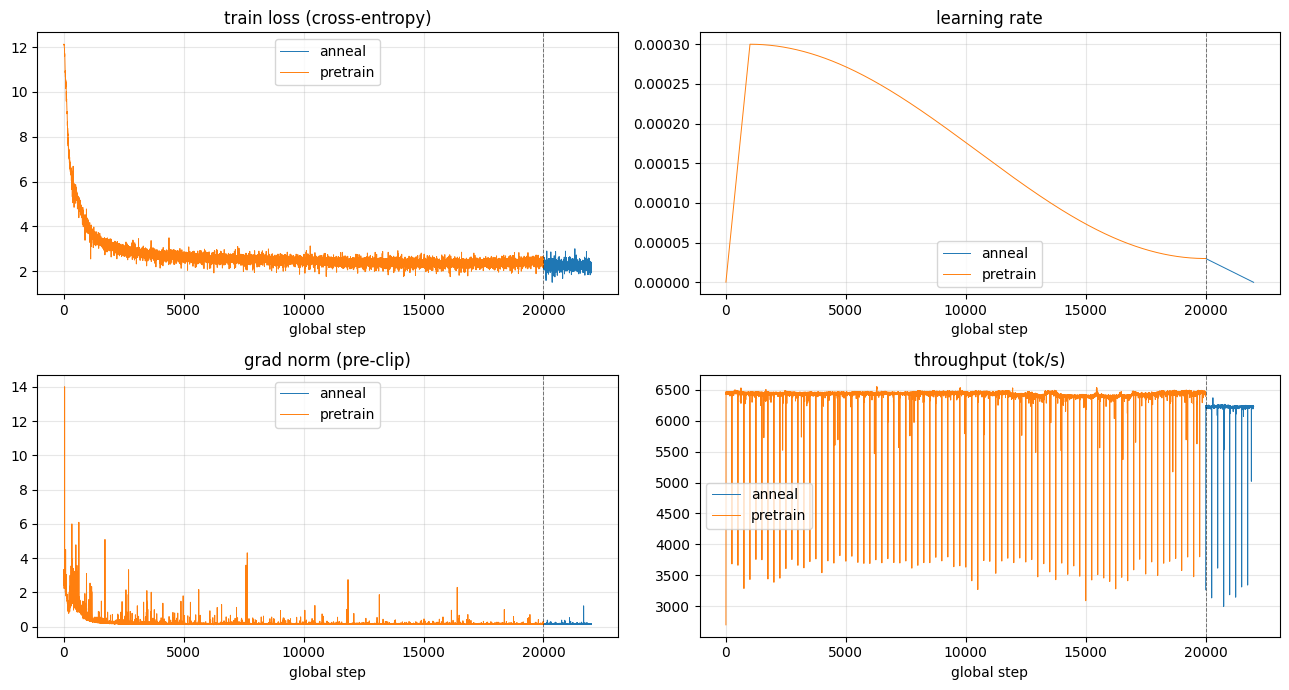

In [7]:
def plot_train_curves(df: pd.DataFrame):
    if not len(df):
        print("no per-step rows to plot"); return
    fig, ax = plt.subplots(2, 2, figsize=(13, 7)); ax = ax.ravel()
    cols   = ["loss", "lr", "gnorm", "tok_per_sec"]
    titles = ["train loss (cross-entropy)", "learning rate",
              "grad norm (pre-clip)", "throughput (tok/s)"]
    for stage, g in df.groupby("stage"):
        for a, c in zip(ax, cols):
            if c in g and g[c].notna().any():
                a.plot(g["gstep"], g[c], lw=0.7, label=stage)
    for a, t in zip(ax, titles):
        a.axvline(PRETRAIN_END_STEP, color="k", ls="--", lw=0.7, alpha=0.5)
        a.set_title(t); a.set_xlabel("global step"); a.legend()
    fig.tight_layout(); plt.show()

plot_train_curves(train_df)

### 4b · Full-run learning curve (pretrain + anneal)

The headline view: training loss across the **entire run** with a moving average,
and the held-out **validation aggregate** overlaid on the same step axis. This is
the single plot that shows the model learning through both stages.

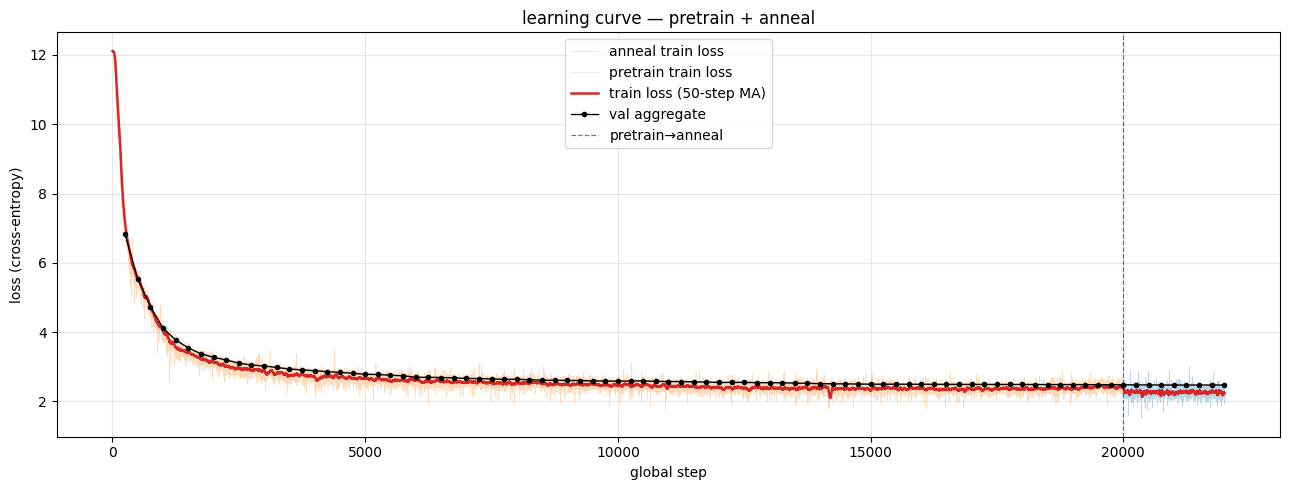

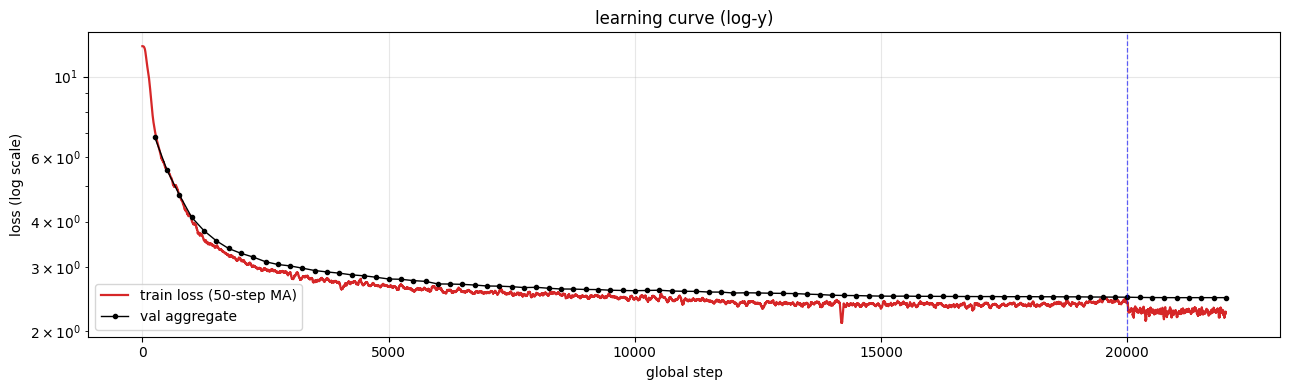

In [8]:
def plot_learning_curve(train_df: pd.DataFrame, val_df: pd.DataFrame):
    if not len(train_df):
        print("no training history to plot"); return
    s = train_df.sort_values("gstep")
    fig, ax = plt.subplots(figsize=(13, 5))

    # train loss per stage (faint) + a global moving average (bold)
    for stage, g in s.groupby("stage"):
        ax.plot(g["gstep"], g["loss"], lw=0.4, alpha=0.30, label=f"{stage} train loss")
    ax.plot(s["gstep"], s["loss"].rolling(50, min_periods=1).mean(),
            color="C3", lw=1.8, label="train loss (50-step MA)")

    # validation aggregate on top (markers), if present
    if len(val_df):
        v = val_df.sort_values("step")
        ax.plot(v["step"], v["aggregate"], color="k", marker="o", ms=3, lw=1.0,
                label="val aggregate")

    ax.axvline(PRETRAIN_END_STEP, color="b", ls="--", lw=0.9, alpha=0.6, label="pretrain→anneal")
    ax.set_xlabel("global step"); ax.set_ylabel("loss (cross-entropy)")
    ax.set_title("learning curve — pretrain + anneal"); ax.legend()
    fig.tight_layout(); plt.show()

    # log-y companion: collapses the steep early descent so late-run progress is visible
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(s["gstep"], s["loss"].rolling(50, min_periods=1).mean(), color="C3", lw=1.6,
            label="train loss (50-step MA)")
    if len(val_df):
        ax.plot(val_df.sort_values("step")["step"], val_df.sort_values("step")["aggregate"],
                color="k", marker="o", ms=3, lw=1.0, label="val aggregate")
    ax.axvline(PRETRAIN_END_STEP, color="b", ls="--", lw=0.9, alpha=0.6)
    ax.set_yscale("log"); ax.set_xlabel("global step"); ax.set_ylabel("loss (log scale)")
    ax.set_title("learning curve (log-y)"); ax.legend()
    fig.tight_layout(); plt.show()

plot_learning_curve(train_df, val_df)

## 5 · Validation curves (the real signal)

Held-out loss per domain plus the aggregate. Train loss can fall through
memorization; **validation** loss is what tells you the model is generalizing.
The dashed line marks the pretrain → anneal handover.

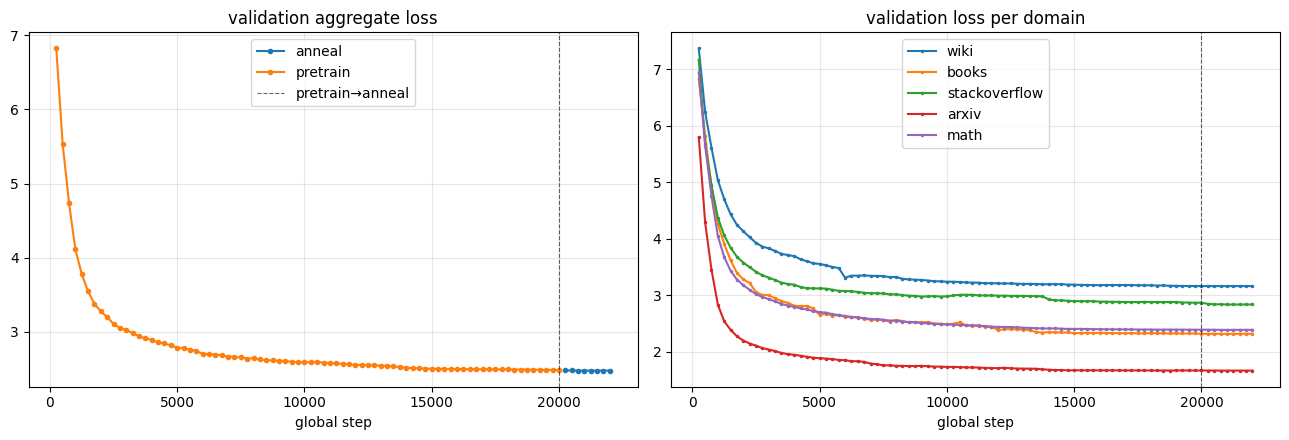

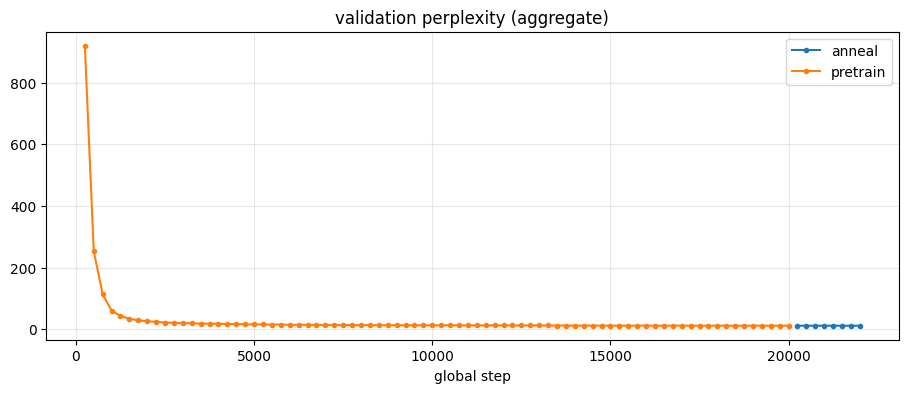

In [9]:
def plot_val_curves(df: pd.DataFrame, domains: list[str]):
    if not len(df):
        print("no validation history found"); return
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    for stage, g in df.groupby("stage"):
        ax[0].plot(g["step"], g["aggregate"], marker="o", ms=3, label=f"{stage}")
    ax[0].axvline(PRETRAIN_END_STEP, color="k", ls="--", lw=0.8, alpha=0.6, label="pretrain→anneal")
    ax[0].set_title("validation aggregate loss"); ax[0].set_xlabel("global step"); ax[0].legend()
    for d in domains:
        ax[1].plot(df["step"], df[d], marker=".", ms=3, label=d)
    ax[1].axvline(PRETRAIN_END_STEP, color="k", ls="--", lw=0.8, alpha=0.6)
    ax[1].set_title("validation loss per domain"); ax[1].set_xlabel("global step"); ax[1].legend()
    fig.tight_layout(); plt.show()

    plt.figure()
    for stage, g in df.groupby("stage"):
        plt.plot(g["step"], np.exp(np.minimum(g["aggregate"], 30)), marker="o", ms=3, label=stage)
    plt.title("validation perplexity (aggregate)"); plt.xlabel("global step"); plt.legend(); plt.show()

plot_val_curves(val_df, DOMAINS)

## 6 · Did annealing help the targeted domains?

The anneal mix up-weights **math** and **arxiv**. The point of the phase is that
those domains improve while the rest hold. We compare the last eval of each stage
per domain (`delta < 0` = annealing lowered the loss = better).

> With the current no-op `anneal_final.pt`, the two columns are identical and
> every delta is ~0 — that's the honest readout until a real anneal run lands.

,domain,pretrain_loss,anneal_loss,delta,pretrain_ppl,anneal_ppl
0,wiki,3.1617,3.1617,0.0000,23.6111,23.6111
1,books,2.3164,2.3172,0.0008,10.1392,10.1471
2,stackoverflow,2.8672,2.8359,-0.0312,17.5875,17.0464
3,arxiv,1.6668,1.6646,-0.0021,5.2952,5.2838
4,math,2.3895,2.3871,-0.0023,10.9075,10.8820
5,aggregate,2.4803,2.4733,-0.0070,11.9450,11.8618


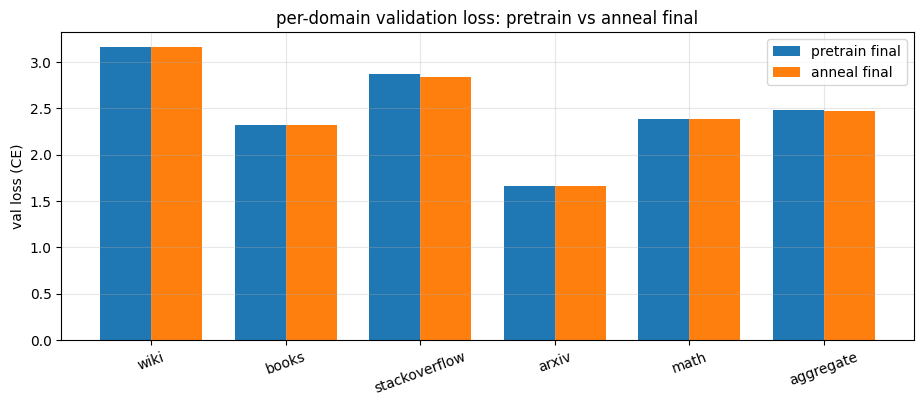

In [10]:
def stage_final_row(df: pd.DataFrame, stage: str):
    g = df[df["stage"] == stage]
    return g.sort_values("step").iloc[-1] if len(g) else None

pre = stage_final_row(val_df, "pretrain")
ann = stage_final_row(val_df, "anneal")
if pre is not None and ann is not None:
    rows = []
    for d in DOMAINS + ["aggregate"]:
        lp, la = float(pre[d]), float(ann[d])
        rows.append(dict(domain=d, pretrain_loss=lp, anneal_loss=la, delta=la - lp,
                         pretrain_ppl=math.exp(min(lp, 30)), anneal_ppl=math.exp(min(la, 30))))
    delta_df = pd.DataFrame(rows)
    display(delta_df.round(4))

    x = np.arange(len(delta_df)); w = 0.38
    plt.figure(figsize=(11, 4))
    plt.bar(x - w/2, delta_df["pretrain_loss"], w, label="pretrain final")
    plt.bar(x + w/2, delta_df["anneal_loss"],   w, label="anneal final")
    plt.xticks(x, delta_df["domain"], rotation=20); plt.ylabel("val loss (CE)")
    plt.title("per-domain validation loss: pretrain vs anneal final"); plt.legend(); plt.show()
else:
    have = ", ".join([s for s, r in [("pretrain", pre), ("anneal", ann)] if r is not None]) or "none"
    print("need both a pretrain and an anneal eval to compare; have:", have)

## 7 · Inference samples emitted during training

`training.py` generates from a fixed prompt every `sample_every` steps. These are
already in the logs — no model load required.

In [11]:
if len(samples_df):
    for _, r in samples_df.iterrows():
        print(f"[{r['stage']:8s} gstep={r['gstep']}] {r['text']}")
else:
    print("no in-training samples logged yet")

[anneal   gstep=20000] The quick brown fox jumps at his master, and the long gray
[anneal   gstep=20000] The quick brown fox jumps at his master, and the long gray
[anneal   gstep=20500] The quick brown fox jumps out of the bushes into the grass, then
[anneal   gstep=20500] The quick brown fox jumps out of the bushes into the grass, then
[anneal   gstep=21000] The quick brown fox jumps over the fence, a
[anneal   gstep=21000] The quick brown fox jumps over the fence, a
[anneal   gstep=21500] The quick brown fox is a rare mammal. Its primary habitat is grassland and it can grow up to about  in height. It also can grow to . It has a snout that is slightly elongated. The tail is black. It has a straight gump on the forelimbs that has a slight
[anneal   gstep=21500] The quick brown fox is a rare mammal. Its primary habitat is grassland and it can grow up to about  in height. It also can grow to . It has a snout that is slightly elongated. The tail is black. It has a straight gump on the fo

## 8 · Live inference samples

Load a checkpoint's weights into the model and generate. This is the heavy step
(≈0.6B params on the GPU), so it's behind `RUN_LIVE_INFERENCE`. We sample from a
general prompt plus reasoning/math/code prompts — the domains the anneal mix
targets — and put pretrain vs anneal side by side.

In [12]:
RUN_LIVE_INFERENCE = True    # set False to skip the model load entirely
INFERENCE_DEVICE   = "auto"  # "auto" | "cuda" | "cpu"
#   This box shares the 5090 with training / a vLLM server, so the GPU is often
#   full. "auto" uses the GPU only if it has headroom and otherwise falls back to
#   CPU (slower, but it always works). Force "cpu" if you hit an OOM.

PROMPTS = [
    "The quick brown fox",
    "In this paper, we prove that",
    "To solve the equation 2x + 6 = 10, we",
    "def fibonacci(n):",
    "The capital of France is",
]

def pick_device(pref: str = "auto"):
    if pref == "cpu" or not torch.cuda.is_available():
        return torch.device("cpu")
    if pref == "cuda":
        return torch.device("cuda")
    free, _ = torch.cuda.mem_get_info()           # auto: need a few GB for weights + activations
    return torch.device("cuda") if free > 3 * 1024**3 else torch.device("cpu")

if RUN_LIVE_INFERENCE:
    from bootstrap import build_model
    from training import load_resume_state, generate_sample_text
    torch.manual_seed(123)

    device = pick_device(INFERENCE_DEVICE)
    if device.type == "cpu" and INFERENCE_DEVICE == "auto":
        print("GPU busy / no headroom — falling back to CPU (set INFERENCE_DEVICE='cuda' to force).")
    print("inference device:", device)

    def load_for_inference(ckpt_path: Path, device):
        model, model_cfg = build_model("0.6b", device)
        load_resume_state(ckpt_path, model, optimizer=None)  # weights only
        model.eval()
        return model, model_cfg

    def sample_suite(model, model_cfg, prompts, device, temperature=0.8, top_k=50, max_new_tokens=60):
        return {p: generate_sample_text(model, p, device,
                                        context_length=model_cfg["context_length"],
                                        max_new_tokens=max_new_tokens,
                                        temperature=temperature, top_k=top_k)
                for p in prompts}
    print("ready — run the next cell to generate")
else:
    print("RUN_LIVE_INFERENCE = False — skipping model load")

inference device: cuda
ready — run the next cell to generate


In [13]:
if RUN_LIVE_INFERENCE:
    results = {}
    for tag, ckpt in [("pretrain", pretrain_ckpt), ("anneal", anneal_ckpt)]:
        if not (ckpt and ckpt.exists()):
            continue
        print(f"=== loading {tag}: {ckpt.name} on {device} ===")
        try:
            model, model_cfg = load_for_inference(ckpt, device)
            results[tag] = sample_suite(model, model_cfg, PROMPTS, device)
            del model
        except torch.cuda.OutOfMemoryError:
            print(f"  GPU OOM on {tag} — set INFERENCE_DEVICE='cpu' above and re-run §8.")
            break
        finally:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    for p in PROMPTS:
        print("\n" + "=" * 100)
        print("PROMPT:", repr(p))
        for tag, gen in results.items():
            txt = gen[p].replace("<|endoftext|>", " <eot> ")
            print(f"\n--- {tag} ---\n{txt}")

2026-06-10 21:06:44,788 | INFO    | v2.boot      | building model 0.6b on cuda (dtype=torch.bfloat16)


=== loading pretrain: qwen3_v2_pretrain_final.pt on cuda ===


2026-06-10 21:06:48,122 | INFO    | v2.boot      | model built: 596,049,920 params (440,467,456 non-embedding)
2026-06-10 21:06:51,002 | INFO    | httpx        | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-0.6B-Base/resolve/main/tokenizer.json "HTTP/1.1 307 Temporary Redirect"
2026-06-10 21:06:51,017 | INFO    | httpx        | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B-Base/da87bfb608c14b7cf20ba1ce41287e8de496c0cd/tokenizer.json "HTTP/1.1 200 OK"
2026-06-10 21:06:55,518 | INFO    | v2.boot      | building model 0.6b on cuda (dtype=torch.bfloat16)


=== loading anneal: qwen3_v2_anneal_final.pt on cuda ===


2026-06-10 21:06:58,636 | INFO    | v2.boot      | model built: 596,049,920 params (440,467,456 non-embedding)



PROMPT: 'The quick brown fox'

--- pretrain ---
The quick brown fox jumps at his master, and the long gray
brown fox is the most amusing of children.  His legs are short, with
long toes, and a short tail, which is long and thick, and has long
tail-lines.  An old woman at the back of the house and at

--- anneal ---
The quick brown fox, who was now on his way to the
market, was in danger of being attacked. It had not been a very
unpleasant and dangerous night; but that night and a half of
morning,--a strange and terrible night, that for which the old
Beeches was

PROMPT: 'In this paper, we prove that'

--- pretrain ---
In this paper, we prove that \(\Lambda_{\alpha-2}=\Lambda_{\alpha}\). We also prove that if \(h=\Lambda_{\alpha}\) then \(\beta_{\alpha}=\beta_{\alpha-2}\). We derive the analogous result for \(h=2\) in SS

--- anneal ---
In this paper, we prove that there exists an infinite set that contains all the primes up to \(2\). We also show that it contains \(M\) and that there 

## 9 · Benchmarks for a pretrained model

Loss/perplexity tell you the model fits the data; **benchmarks** tell you what it
can *do*. For a base (non-instruct) LM the standard ones are zero-/few-shot:

**Perplexity / likelihood (cheapest, tokenizer-aware)**
- **WikiText-103 perplexity**, **bits-per-byte (BPB)** on a held-out corpus —
  tokenizer-agnostic via BPB, directly comparable across models.

**Cloze / completion accuracy**
- **LAMBADA** — predict the last word of a passage (needs long-range context).
- **HellaSwag**, **WinoGrande**, **PIQA** — commonsense sentence completion.

**Multiple-choice knowledge / reasoning**
- **ARC-easy / ARC-challenge**, **OpenBookQA**, **BoolQ**, **MMLU** (5-shot),
  **SciQ** — measured by length-normalized log-likelihood of each option.

**The practical way to run them:** [EleutherAI **lm-evaluation-harness**]. It
expects an HF-format model, so two scripts in this folder do the work — the
exporter remaps our weights into a `Qwen3ForCausalLM` shell (architecturally
identical: GQA + QK-norm, SwiGLU, RoPE θ=1e6, tied embeddings) and *verifies*
top-1 logit parity against the native model before writing; the runner drives
the harness over a base-model task suite.

```bash
# one-time: pull the eval deps (transformers, lm-eval, accelerate)
uv sync --group eval

# 1) export a checkpoint -> HF folder (self-verifying)
uv run python notebooks/export_hf.py \
    --ckpt checkpoints/qwen3_v2_anneal_final.pt \
    --out  exports/qwen3_v2_anneal_hf

# 2) benchmark it (full base-model suite; results -> notebooks/bench_results/)
notebooks/run_lm_eval.sh exports/qwen3_v2_anneal_hf

# quick smoke run on a few examples:
DEVICE=cuda:0 LIMIT=20 TASKS=lambada_openai,piqa notebooks/run_lm_eval.sh
```

Export `qwen3_v2_pretrain_final.pt` the same way to get a clean
**pretrain-vs-anneal** table over identical tasks. Note the model was *trained*
at context 2048; `export_hf.py --max-position-embeddings` defaults to Qwen3's
native 40960 (RoPE extends), set 2048 to be strict.

**Calibrate expectations.** This is a 0.6B model trained from scratch on ~10B
tokens (vs. trillions for production models). Expect: WikiText/LAMBADA-ppl that's
*reasonable*, LAMBADA accuracy well below SOTA, and the hard MCQ tasks (MMLU,
ARC-c) **near random** — that's normal at this scale/budget. The likelihood and
LAMBADA/HellaSwag numbers are the informative ones here; treat MMLU as a sanity
floor, not a target.

The cell below runs a **self-contained** benchmark that needs no external
datasets — per-domain **perplexity** and **next-token top-1 accuracy** on the
held-out validation sets, which is a legitimate quantitative comparison between
checkpoints. (Heavier: builds val loaders + runs the model, so it's off by default.)

In [14]:
RUN_BENCHMARK = False   # set True (and ideally a free GPU) to run; uses pick_device() from §8
BENCH_BATCHES = 20      # batches per domain
BENCH_CKPT    = anneal_ckpt if (anneal_ckpt and anneal_ckpt.exists()) else pretrain_ckpt

if RUN_BENCHMARK:
    import torch.nn.functional as F
    from data import build_val_loaders
    from bootstrap import build_model
    from training import load_resume_state

    dev = pick_device(INFERENCE_DEVICE)
    print(f"benchmarking {BENCH_CKPT.name} on {dev}")
    bm_model, bm_cfg = build_model("0.6b", dev)
    load_resume_state(BENCH_CKPT, bm_model, optimizer=None)
    bm_model.eval()

    val_loaders = build_val_loaders(context_length=bm_cfg["context_length"],
                                    batch_size=4, val_docs_per_source=200)
    rows = []
    with torch.no_grad():
        for name, loader in val_loaders.items():
            tot_loss = tot_tok = correct = 0
            for i, (x, y) in enumerate(loader):
                if i >= BENCH_BATCHES:
                    break
                x, y = x.to(dev), y.to(dev)
                logits = bm_model(x)
                tot_loss += F.cross_entropy(logits.flatten(0, 1), y.flatten(), reduction="sum").item()
                correct  += (logits.argmax(-1) == y).sum().item()
                tot_tok  += y.numel()
            rows.append(dict(domain=name, tokens=tot_tok,
                             perplexity=math.exp(tot_loss / max(tot_tok, 1)),
                             top1_acc=correct / max(tot_tok, 1)))
    bench_df = pd.DataFrame(rows)
    bench_df.loc["mean"] = ["(macro avg)", bench_df["tokens"].sum(),
                            bench_df["perplexity"].mean(), bench_df["top1_acc"].mean()]
    display(bench_df.round(4))
else:
    print("RUN_BENCHMARK = False — set True to compute per-domain perplexity + next-token accuracy.")
    print("For standard benchmarks (LAMBADA/HellaSwag/ARC/MMLU) use export_hf.py + run_lm_eval.sh (recipe above).")

RUN_BENCHMARK = False — set True to compute per-domain perplexity + next-token accuracy.
For standard benchmarks (LAMBADA/HellaSwag/ARC/MMLU) use export_hf.py + run_lm_eval.sh (recipe above).


## 10 · Which metrics to watch — and why

**Run health (is training proceeding correctly?)**

| Metric | Read it for | Healthy looks like |
|---|---|---|
| **Train loss** (cross-entropy) | Is it learning at all? | Smooth downward trend |
| **Perplexity** = `exp(loss)` | Interpretable loss (avg branching factor) | Falls toward single digits |
| **Learning rate** | Did warmup/decay actually execute? | Matches the planned schedule¹ |
| **Grad norm** (pre-clip) | Optimization stability | Stable; no spikes, not collapsing to ~0 |
| **Throughput** (tok/s, MFU) | Efficiency / hardware health | Flat; drops signal stalls or thermal throttle |
| **Loss vs tokens** (not steps) | Compute-normalized progress | Monotone; lets you compare runs fairly |

¹ This is exactly the class of bug that left annealing a no-op — always verify the
LR curve, not just the loss.

**Model quality (is the model actually good?)**

- **Held-out validation loss / perplexity, per domain** — the primary quality
  signal. The **generalization gap** (val − train) flags overfitting. For the
  anneal phase specifically, watch the **up-weighted domains (math, arxiv)**: the
  whole point is that they improve while the others hold (§6).
- **Token / top-k accuracy** on held-out text — a complement to loss that's less
  sensitive to the tail of the distribution.
- **Downstream zero-/few-shot benchmarks** — even for a 0.6B from scratch, cheap
  ones are informative: **LAMBADA** (last-word accuracy), **HellaSwag**, **ARC-easy**,
  **bits-per-byte**. These measure capability, not just fit to the training mix.
- **Qualitative generations** (§7–8) — coherence, repetition/looping, and whether
  reasoning/code prompts produce structured output. Subjective but catches failure
  modes that loss hides.
- **Anneal delta** — per-domain val before vs. after annealing is the single most
  direct check that the phase did its job.

**Practical tips**

- Compare on **tokens**, not steps, when batch/accum differ between runs.
- A *rising* val loss while train loss falls = overfitting; a *flat* val loss with
  `grad_norm → 0` = saturation / dead LR.
- Keep an eye on **per-domain divergence**: one domain regressing while the
  aggregate looks fine is the failure the per-domain plot in §5 is built to catch.